In [1]:
pip install cartopy pymannkendall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 83.9 MB/s eta 0:00:00


In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
import numpy as np

## Evapotranspiration

#### Monthly mean Map

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


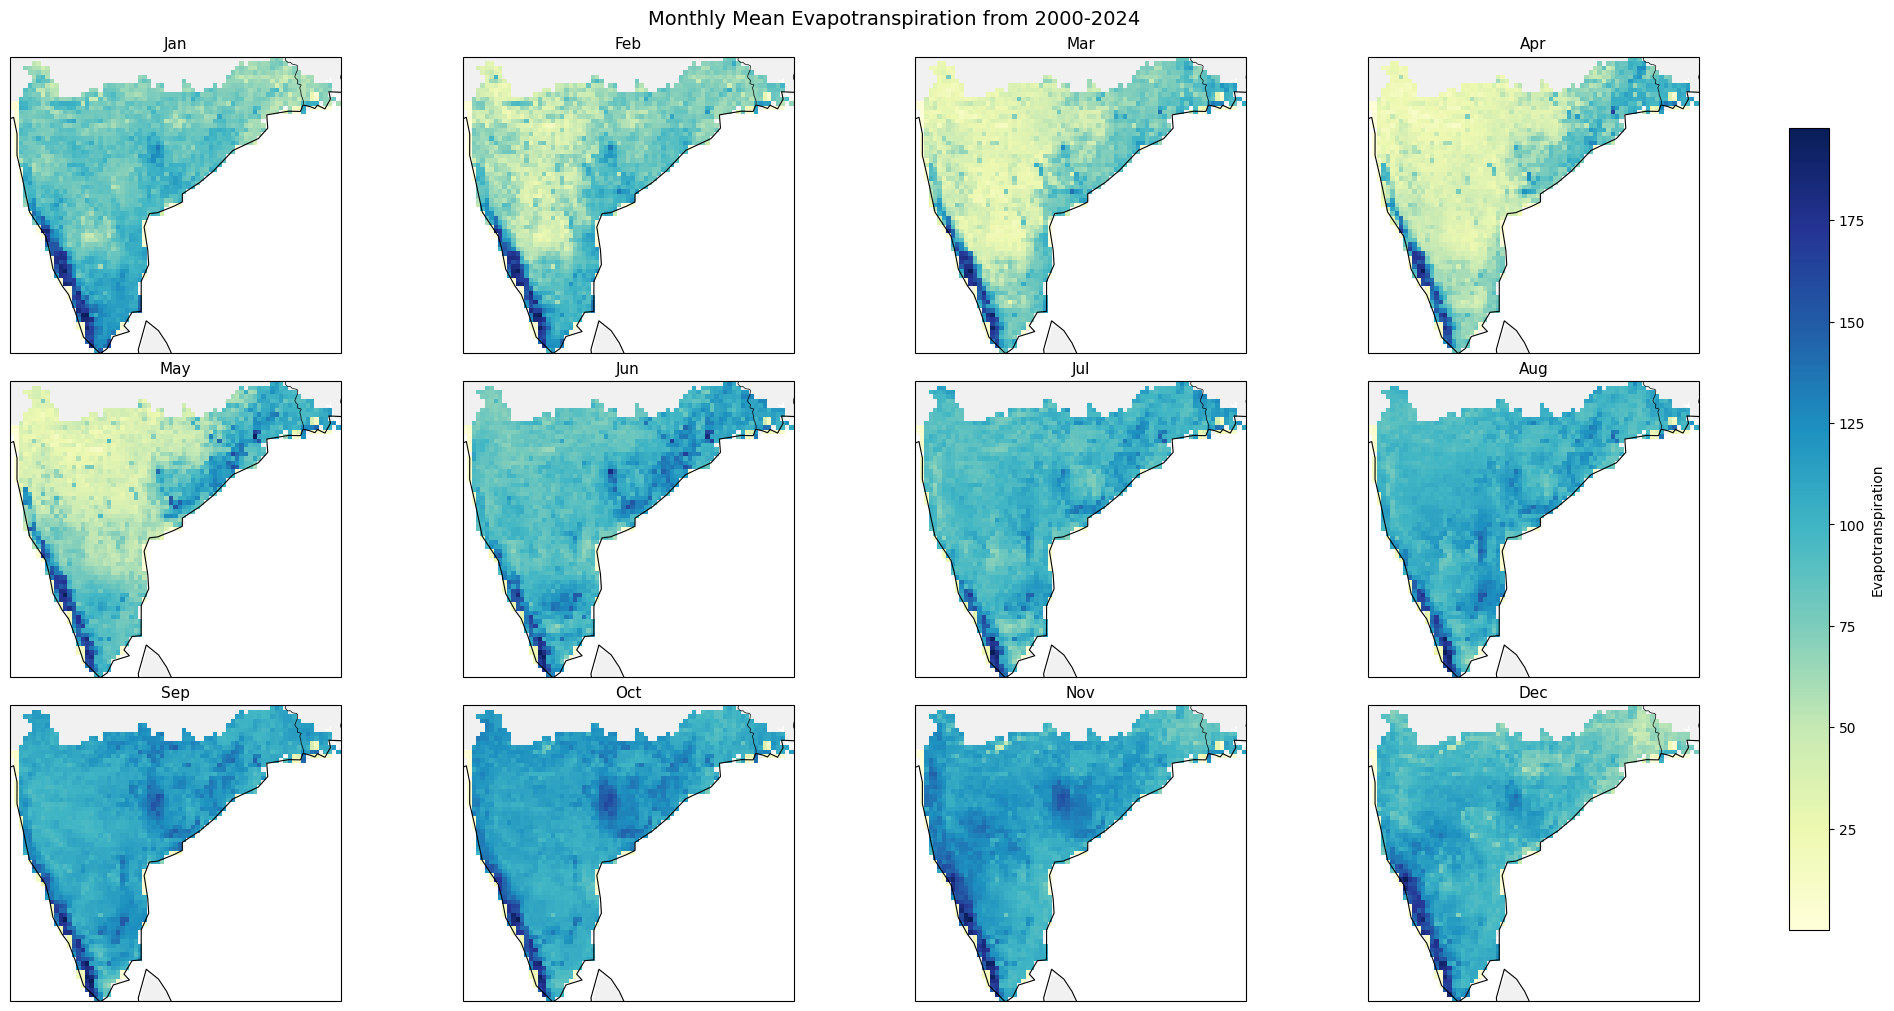

In [3]:
# -------------------------------
# Load NetCDF
# -------------------------------
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Evapotranspiration/GLEAM_Evapotranspiration_resampled_NN.nc")
et = ds["ET"]   # change variable name if needed

# -------------------------------
# Monthly climatology
# -------------------------------
monthly_mean = et.groupby("time.month").mean(dim="time")

# -------------------------------
# Plot settings
# -------------------------------
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGnBu",
        add_colorbar=False
    )

    # Base map features
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    ax.set_title(months[i], fontsize=11)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Evapotranspiration")

plt.suptitle(
    "Monthly Mean Evapotranspiration from 2000-2024",
    fontsize=14
)

plt.show()


#### Mann Kendall Test

In [4]:
# -------------------------------
# Load data
# -------------------------------
et = ds["ET"]   # change variable name if needed

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:   # safety check
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
results = {}

for month in range(1, 13):

    et_m = et.sel(time=et["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        et_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })

# -------------------------------
# Example: January trend map
# -------------------------------
results[1]

<xarray.Dataset> Size: 162kB
Dimensions:     (lat: 67, lon: 75)
Coordinates:
  * lat         (lat) float64 536B 8.15 8.4 8.65 8.9 ... 23.9 24.15 24.4 24.65
  * lon         (lon) float64 600B 72.55 72.8 73.05 73.3 ... 90.55 90.8 91.05
Data variables:
    trend       (lat, lon) object 40kB nan nan nan nan nan ... nan nan nan nan
    z_value     (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan
    p_value     (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan
    sens_slope  (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan

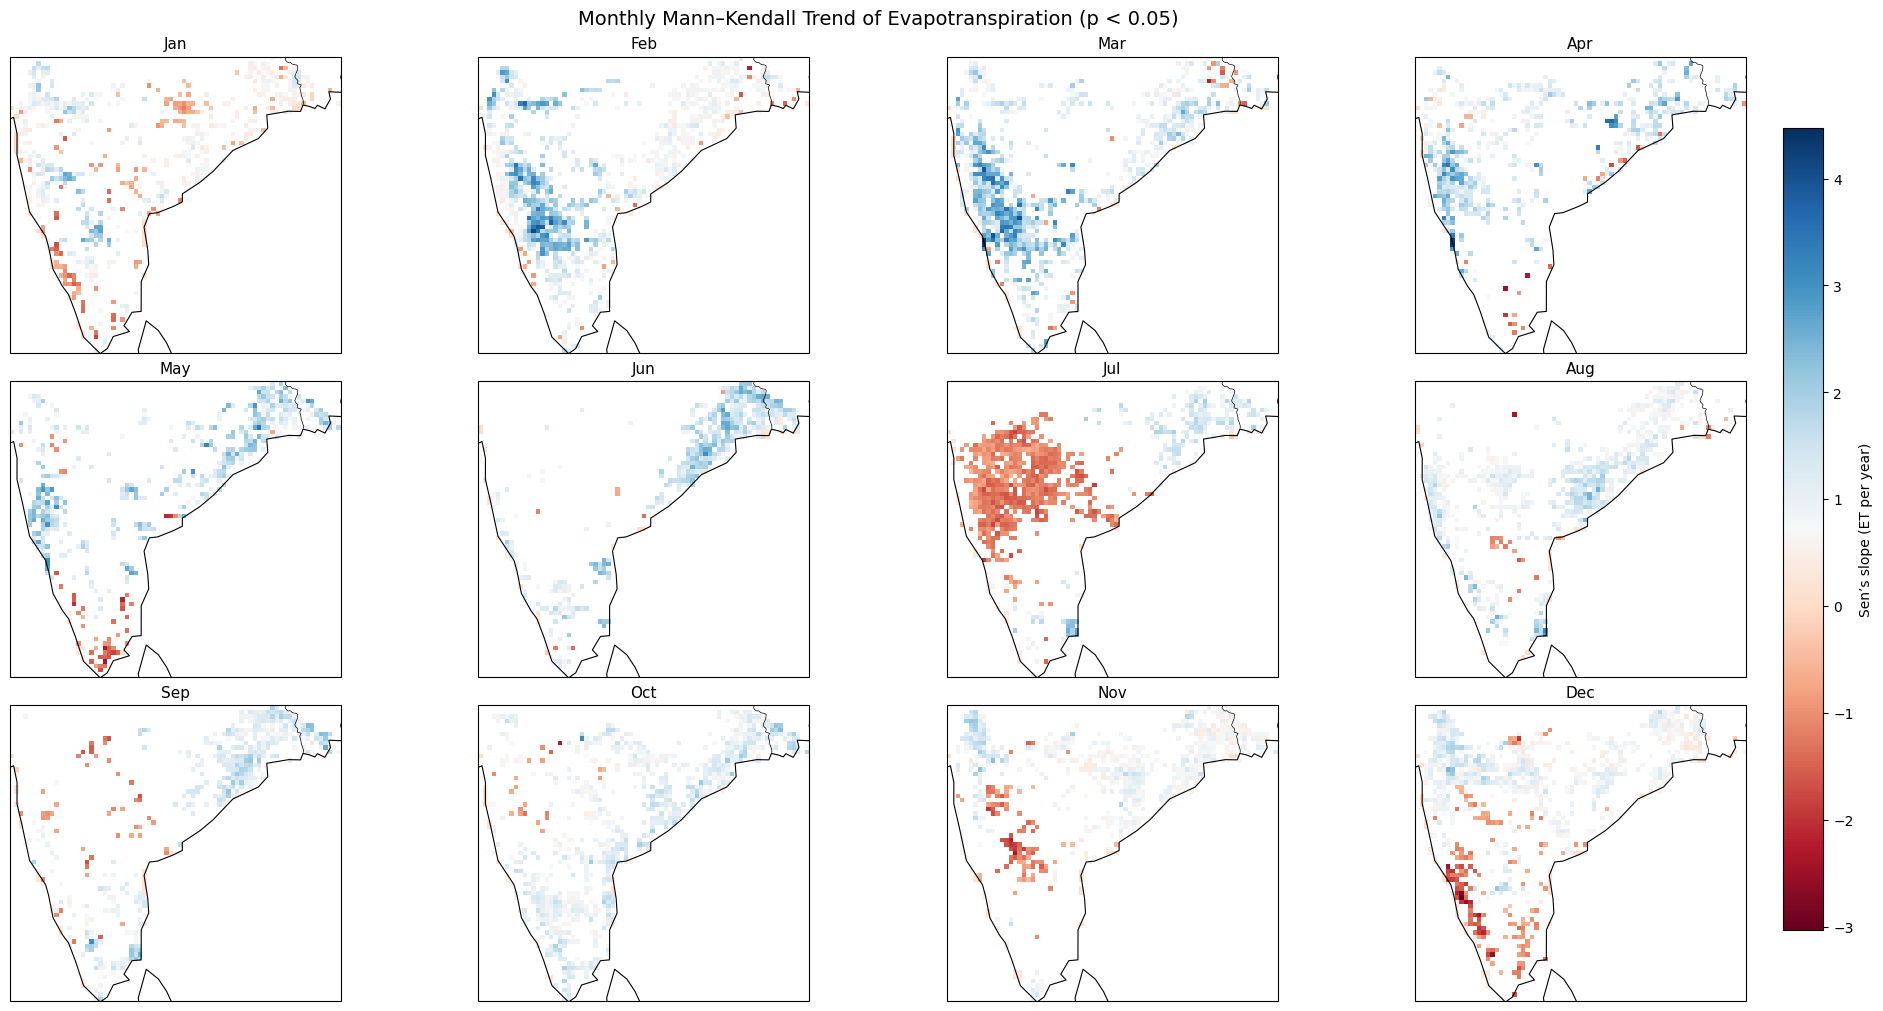

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (important)
# ---------------------------------
all_slopes = []

for m in range(1, 13):
    slope = results[m]["sens_slope"]
    sig = slope.where(results[m]["p_value"] < 0.05)
    all_slopes.append(sig)

vmin = np.nanmin([s.min().values for s in all_slopes])
vmax = np.nanmax([s.max().values for s in all_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1

    ds_mk = results[month]

    sig_slope = ds_mk["sens_slope"].where(
        ds_mk["p_value"] < 0.05
    )

    im = sig_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Basemap
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional: restrict extent (example: India)
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)
cbar.set_label("Sen’s slope (ET per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Evapotranspiration (p < 0.05)",
    fontsize=14
)

plt.show()


## Soil Moisture

#### Monthly Mean Map

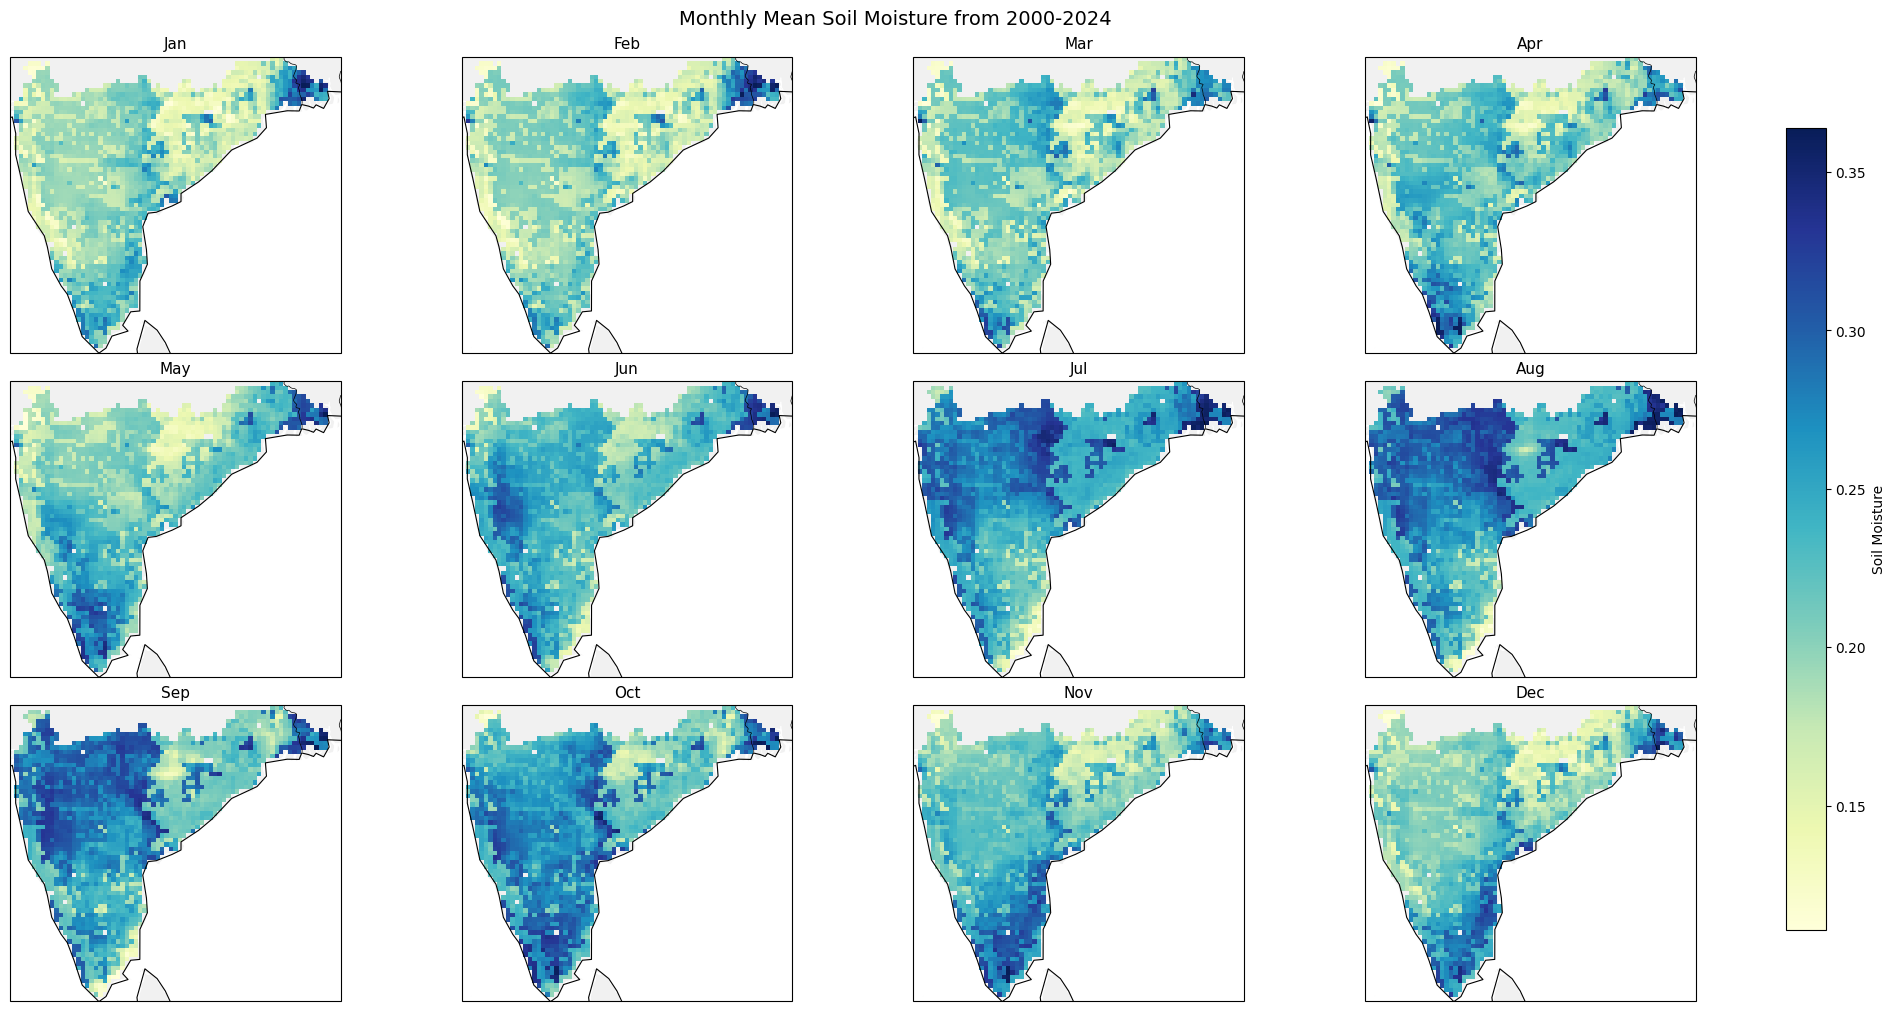

In [ ]:
# -------------------------------
# Load NetCDF
# -------------------------------
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Soil Moisture/SoilMoisture_Crop.nc")
et = ds["sm"]   # change variable name if needed

# -------------------------------
# Monthly climatology
# -------------------------------
monthly_mean = et.groupby("time.month").mean(dim="time")

# -------------------------------
# Plot settings
# -------------------------------
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGnBu",
        add_colorbar=False
    )

    # Base map features
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    ax.set_title(months[i], fontsize=11)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Soil Moisture")

plt.suptitle(
    "Monthly Mean Soil Moisture from 2000-2024",
    fontsize=14
)


plt.show()


#### Mann Kendall Test

In [ ]:
# -------------------------------
# Load data
# -------------------------------
et = ds["sm"]   # change variable name if needed

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:   # safety check
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
results = {}

for month in range(1, 13):

    et_m = et.sel(time=et["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        et_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })

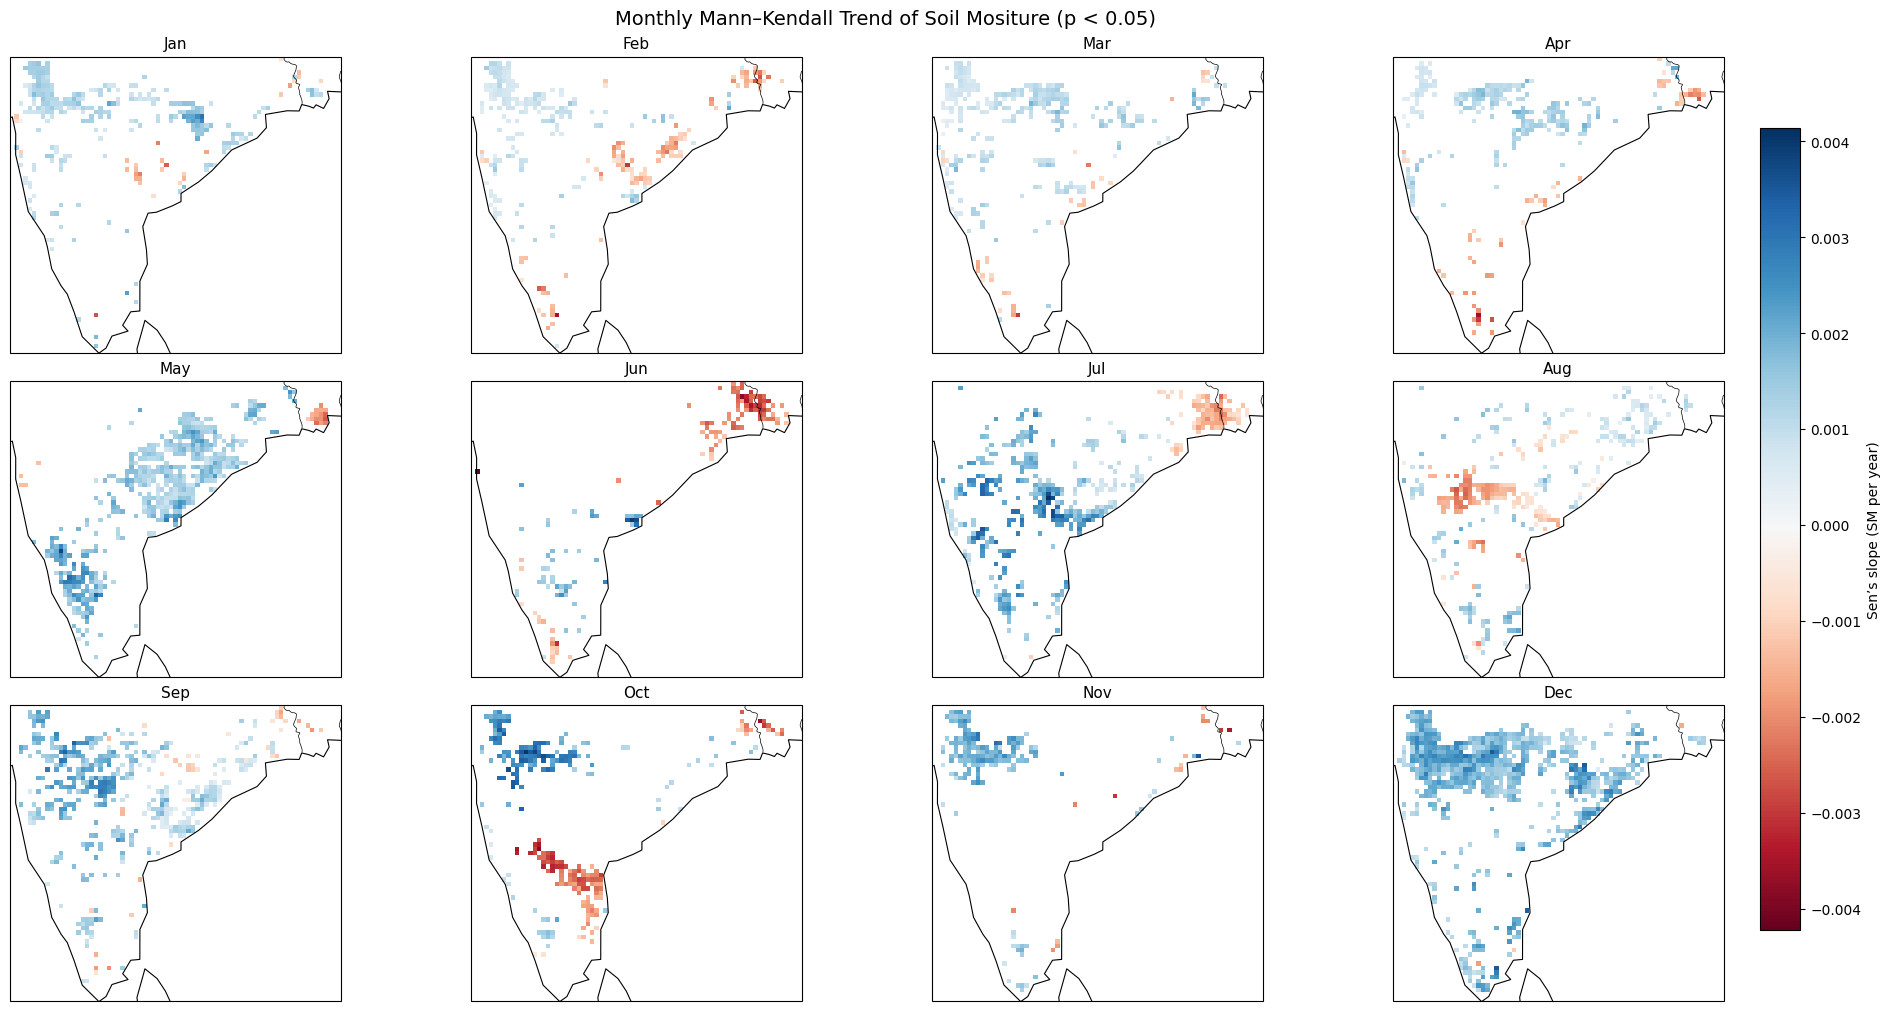

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (important)
# ---------------------------------
all_slopes = []

for m in range(1, 13):
    slope = results[m]["sens_slope"]
    sig = slope.where(results[m]["p_value"] < 0.05)
    all_slopes.append(sig)

vmin = np.nanmin([s.min().values for s in all_slopes])
vmax = np.nanmax([s.max().values for s in all_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1

    ds_mk = results[month]

    sig_slope = ds_mk["sens_slope"].where(
        ds_mk["p_value"] < 0.05
    )

    im = sig_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Basemap
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional: restrict extent (example: India)
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)
cbar.set_label("Sen’s slope (SM per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Soil Mositure (p < 0.05)",
    fontsize=14
)

plt.show()


## Runoff

#### Monthly Mean Map

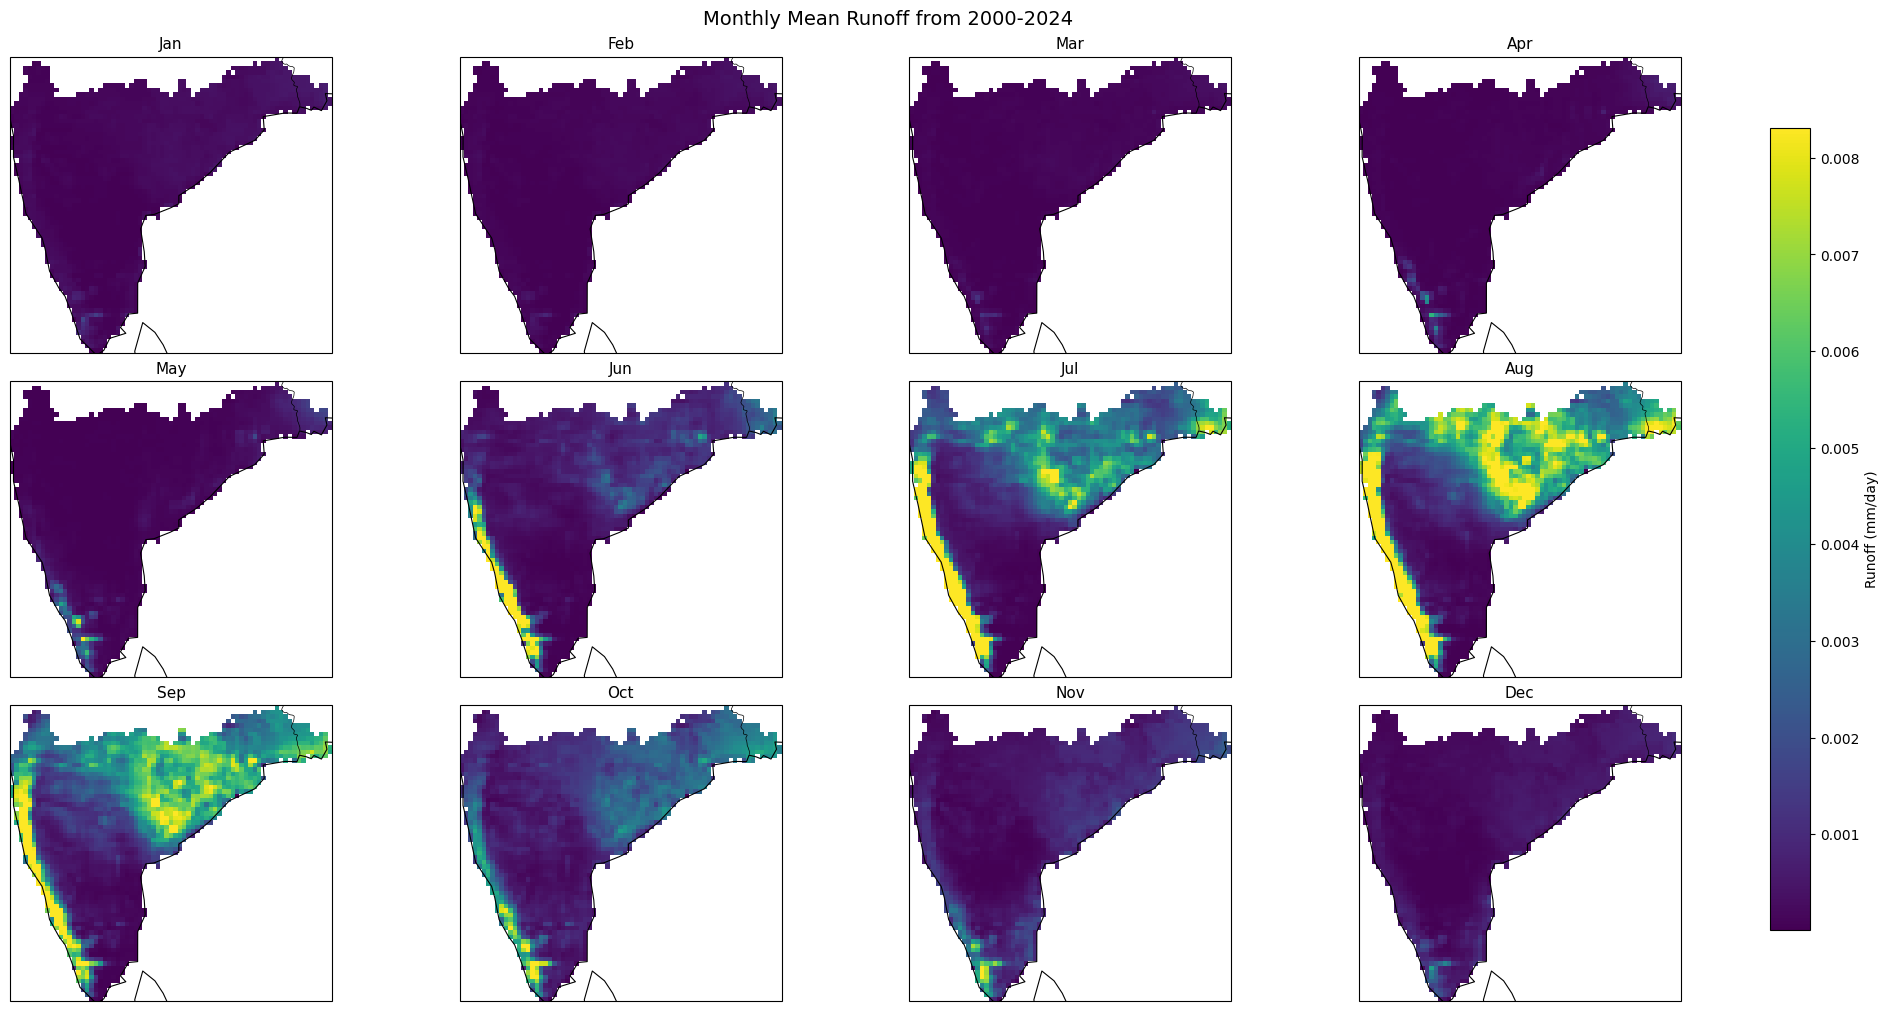

In [ ]:
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Runoff/Runoff_cropped.nc")
ro = ds["ro"]

monthly_mean = ro.groupby("valid_time.month").mean(dim="valid_time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Runoff (mm/day)")

plt.suptitle(
    "Monthly Mean Runoff from 2000-2024",
    fontsize=14
)

plt.show()

#### Mann Kendall Test

In [ ]:
# -------------------------------
# Load data
# -------------------------------
ro = ds["ro"]

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
results = {}

for month in range(1, 13):

    # Select month using correct time dimension
    ro_m = ro.sel(valid_time=ro["valid_time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        ro_m,
        input_core_dims=[["valid_time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


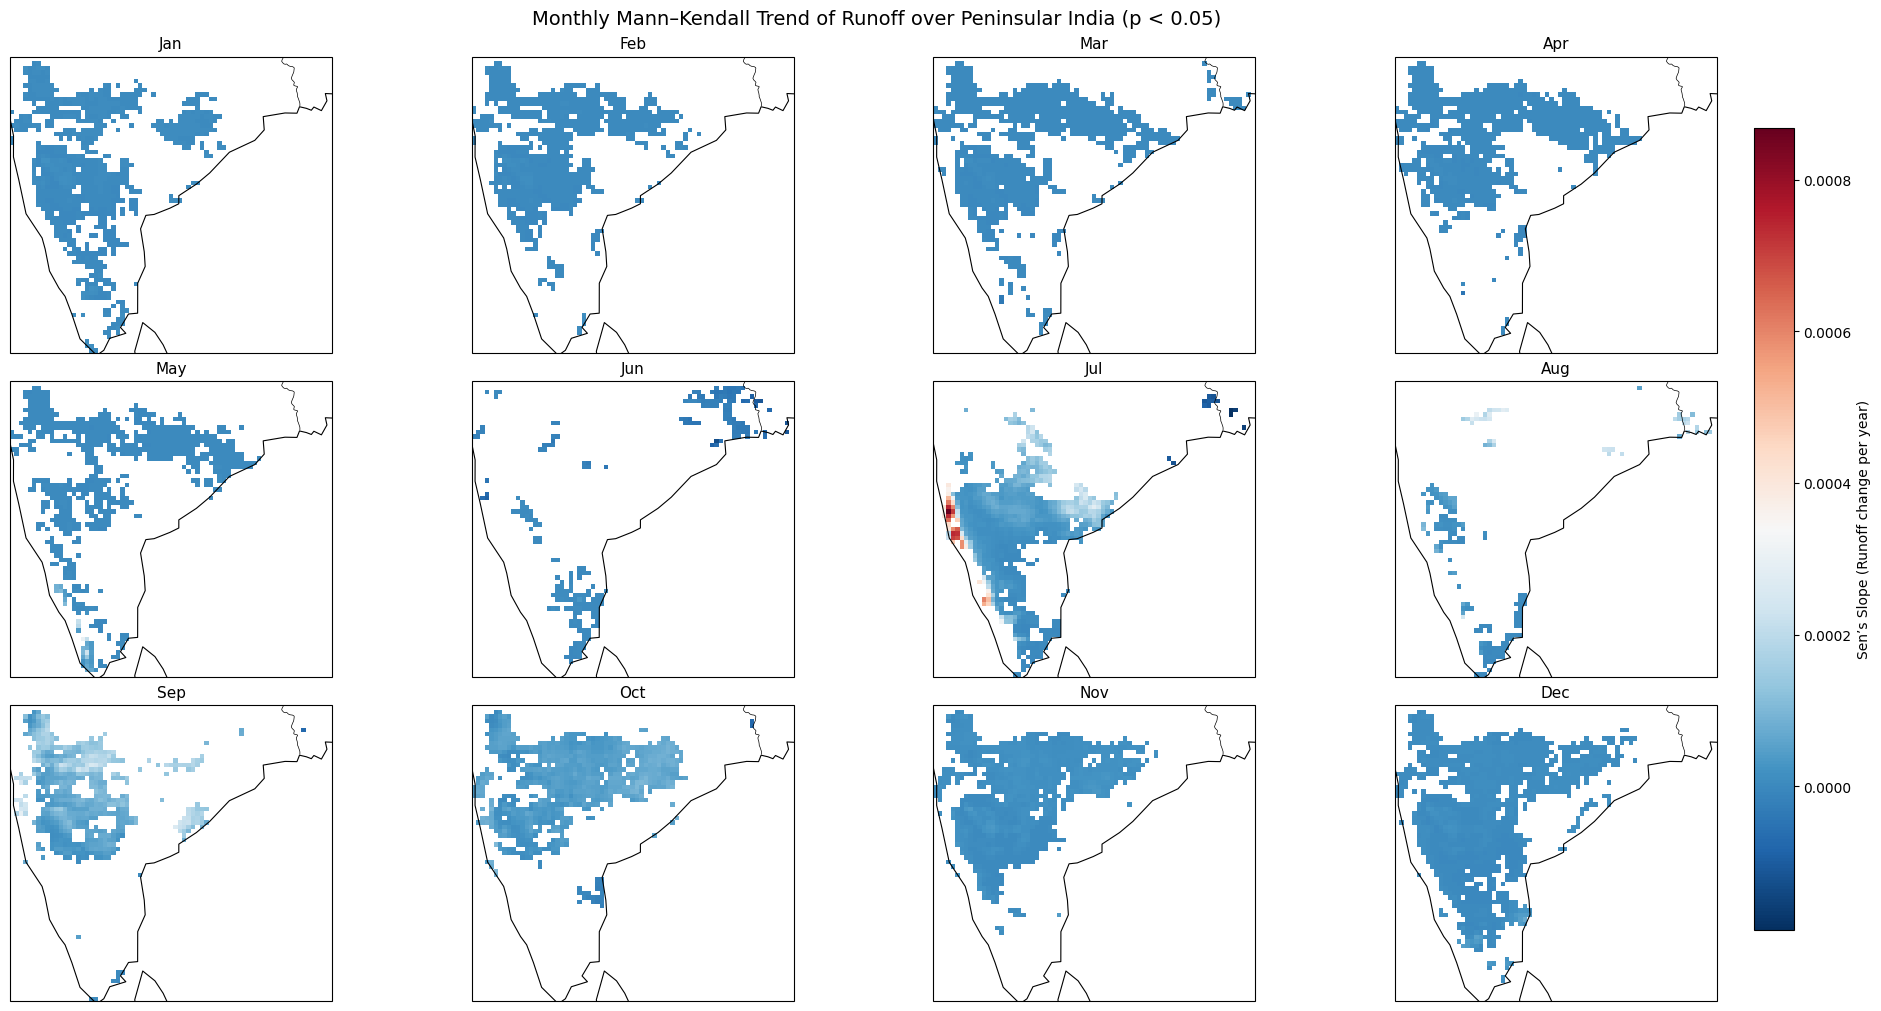

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant runoff slopes only)
# ---------------------------------
all_runoff_slopes = []

for m in range(1, 13):
    runoff_slope = results[m]["sens_slope"]
    significant_slope = runoff_slope.where(results[m]["p_value"] < 0.05)
    all_runoff_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_runoff_slopes])
vmax = np.nanmax([s.max().values for s in all_runoff_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    runoff_mk = results[month]

    significant_slope = runoff_mk["sens_slope"].where(
        runoff_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",   # reversed for intuitive blue=decrease, red=increase
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Runoff change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Runoff over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()

## Precipitation

Monthly Mean Map

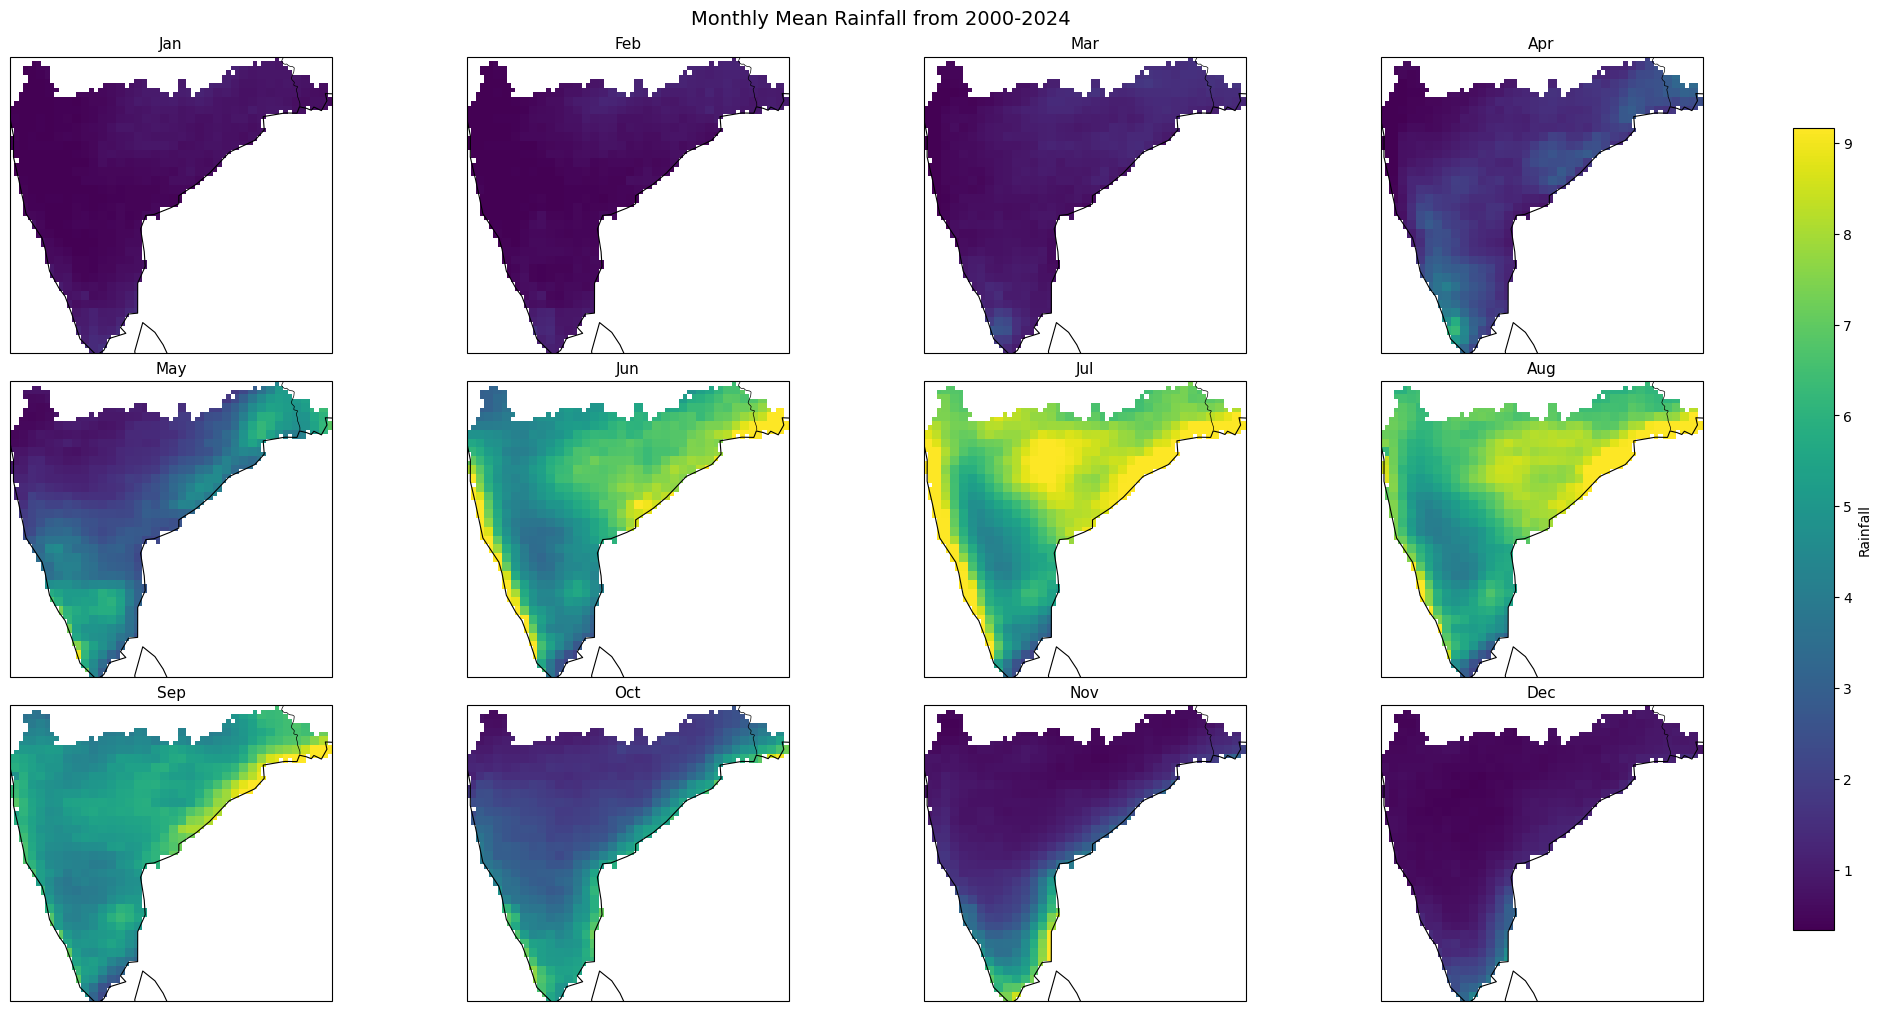

In [ ]:
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Precipitation/Rainfall_Resample_Cropped.nc")
rf = ds["satellite_precip"]

monthly_mean = rf.groupby("time.month").mean(dim="time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Rainfall")

plt.suptitle(
    "Monthly Mean Rainfall from 2000-2024",
    fontsize=14
)

plt.show()

#### Mann Kendall Test

In [ ]:
# -------------------------------
# Load rainfall data
# -------------------------------
rain = ds["satellite_precip"]

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
rain_results = {}

for month in range(1, 13):

    # Select monthly rainfall
    rain_m = rain.sel(time=rain["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        rain_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    rain_results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


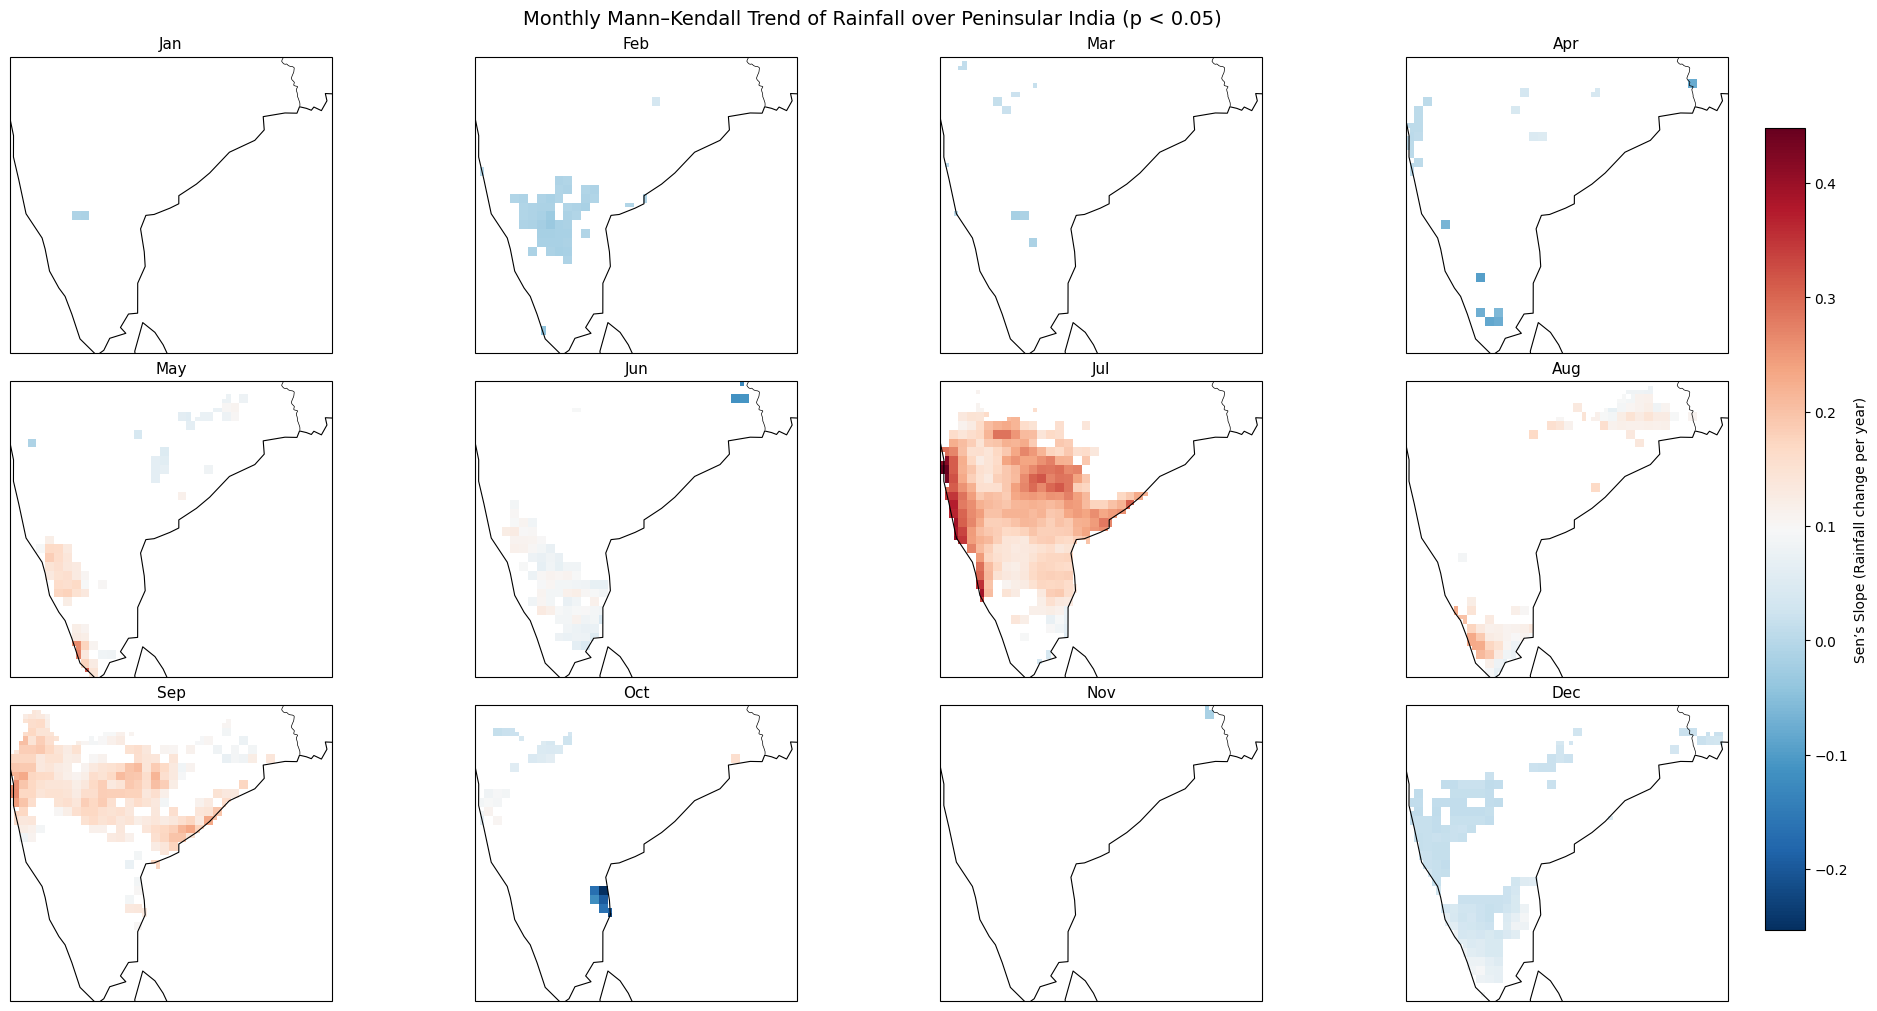

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant rainfall slopes only)
# ---------------------------------
all_rain_slopes = []

for m in range(1, 13):
    rain_slope = rain_results[m]["sens_slope"]
    significant_slope = rain_slope.where(rain_results[m]["p_value"] < 0.05)
    all_rain_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_rain_slopes])
vmax = np.nanmax([s.max().values for s in all_rain_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    rainfall_mk = rain_results[month]

    significant_slope = rainfall_mk["sens_slope"].where(
        rainfall_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Rainfall change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Rainfall over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()


## GLDAS Groundwater Data

#### Monthly Mean Map

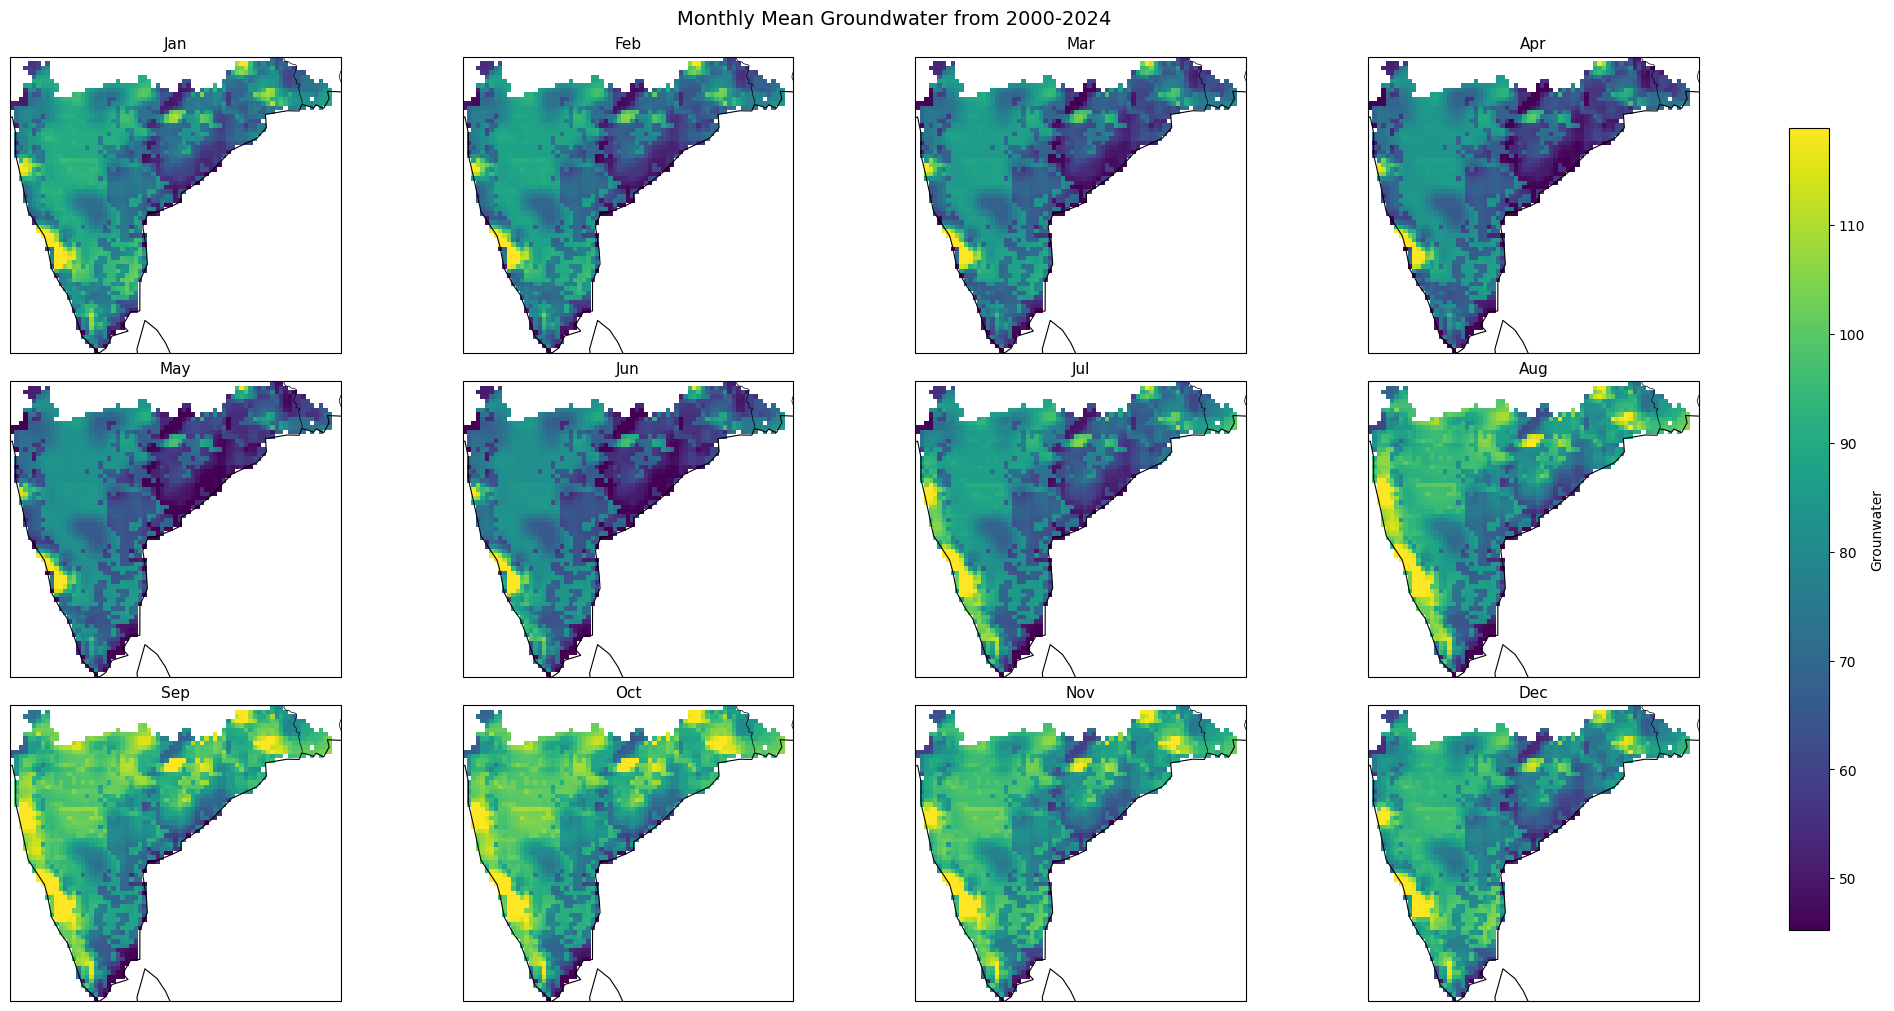

In [ ]:
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Groundwater/PENINSULAR_INDIA_GLDAS_GWS_cm_Monthly_2003_2024.nc")
gw = ds["GWS_tavg"]

monthly_mean = gw.groupby("time.month").mean(dim="time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Grounwater")

plt.suptitle(
    "Monthly Mean Groundwater from 2000-2024",
    fontsize=14
)

plt.show()

#### Mann Kendall Test

In [ ]:
# -------------------------------
# Load groundwater data
# -------------------------------
rain = ds["GWS_tavg"]

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
rain_results = {}

for month in range(1, 13):

    # Select monthly rainfall
    rain_m = rain.sel(time=rain["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        rain_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    rain_results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


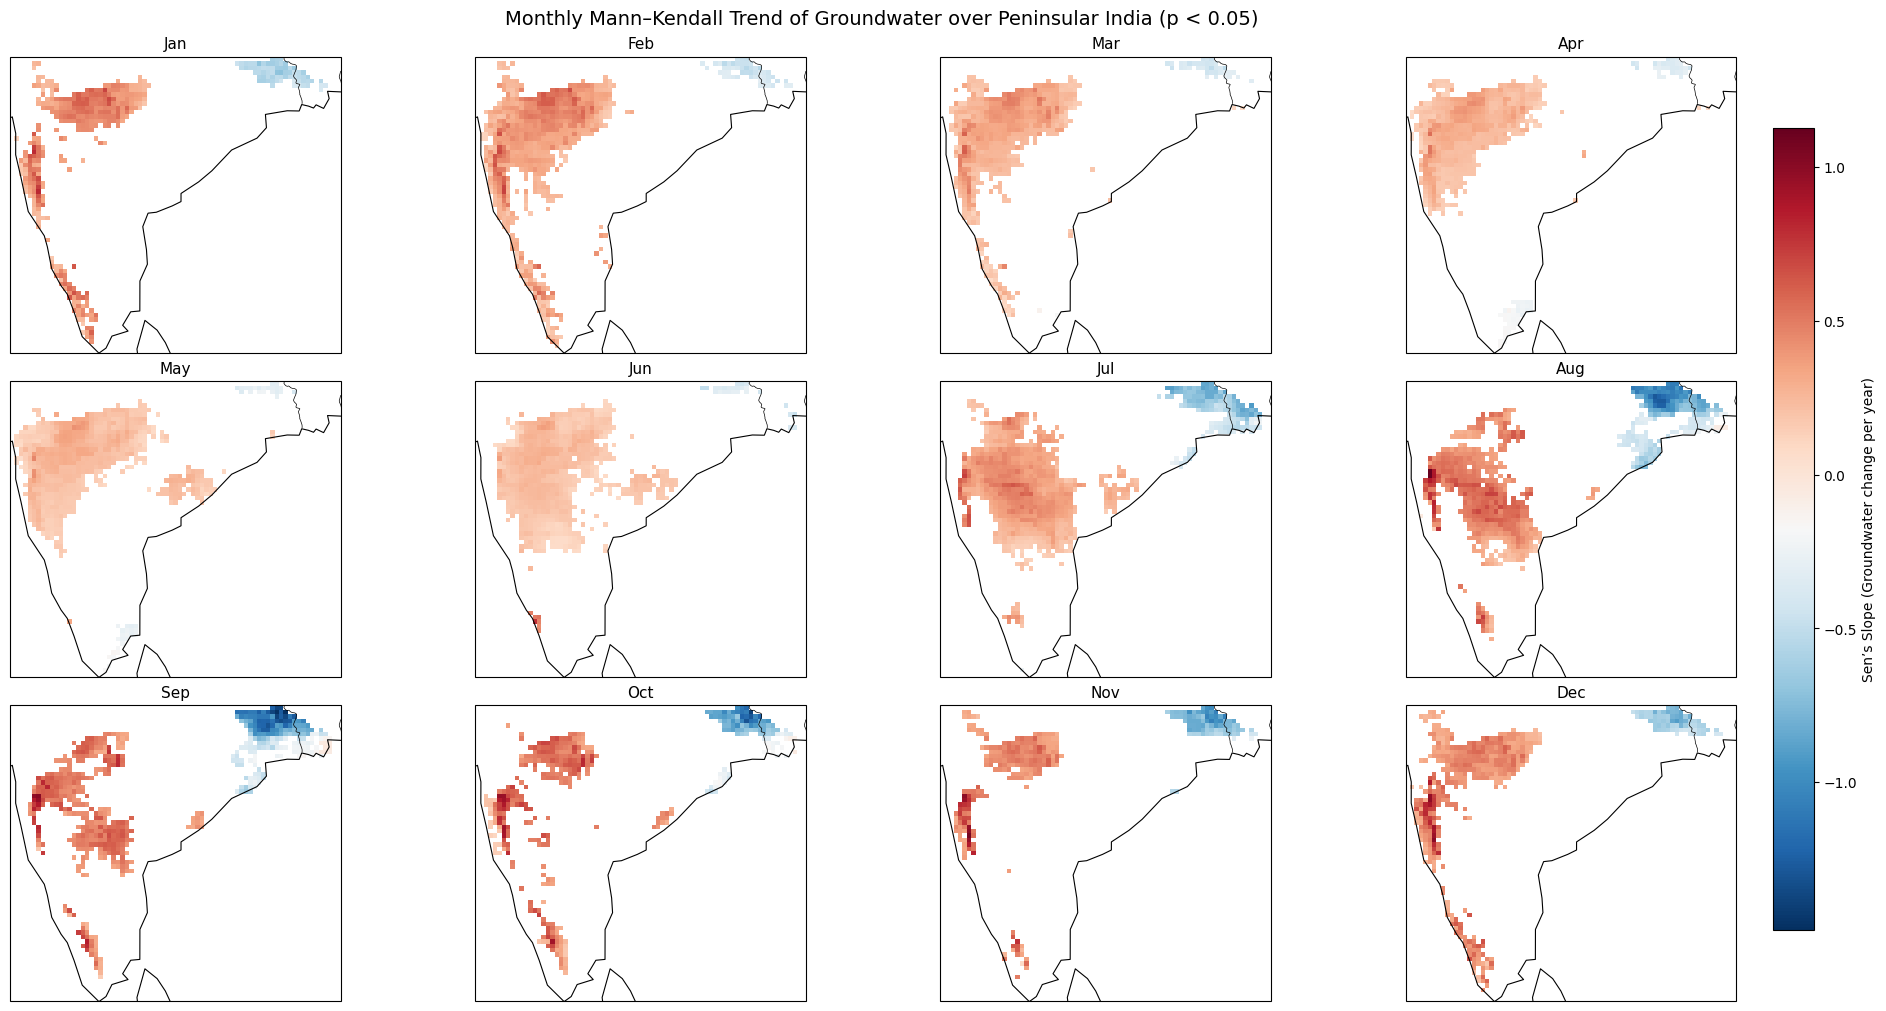

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant rainfall slopes only)
# ---------------------------------
all_rain_slopes = []

for m in range(1, 13):
    rain_slope = rain_results[m]["sens_slope"]
    significant_slope = rain_slope.where(rain_results[m]["p_value"] < 0.05)
    all_rain_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_rain_slopes])
vmax = np.nanmax([s.max().values for s in all_rain_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    rainfall_mk = rain_results[month]

    significant_slope = rainfall_mk["sens_slope"].where(
        rainfall_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Groundwater change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Groundwater over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()


## GRACE Groundwater Data

Monthly Mean Maps

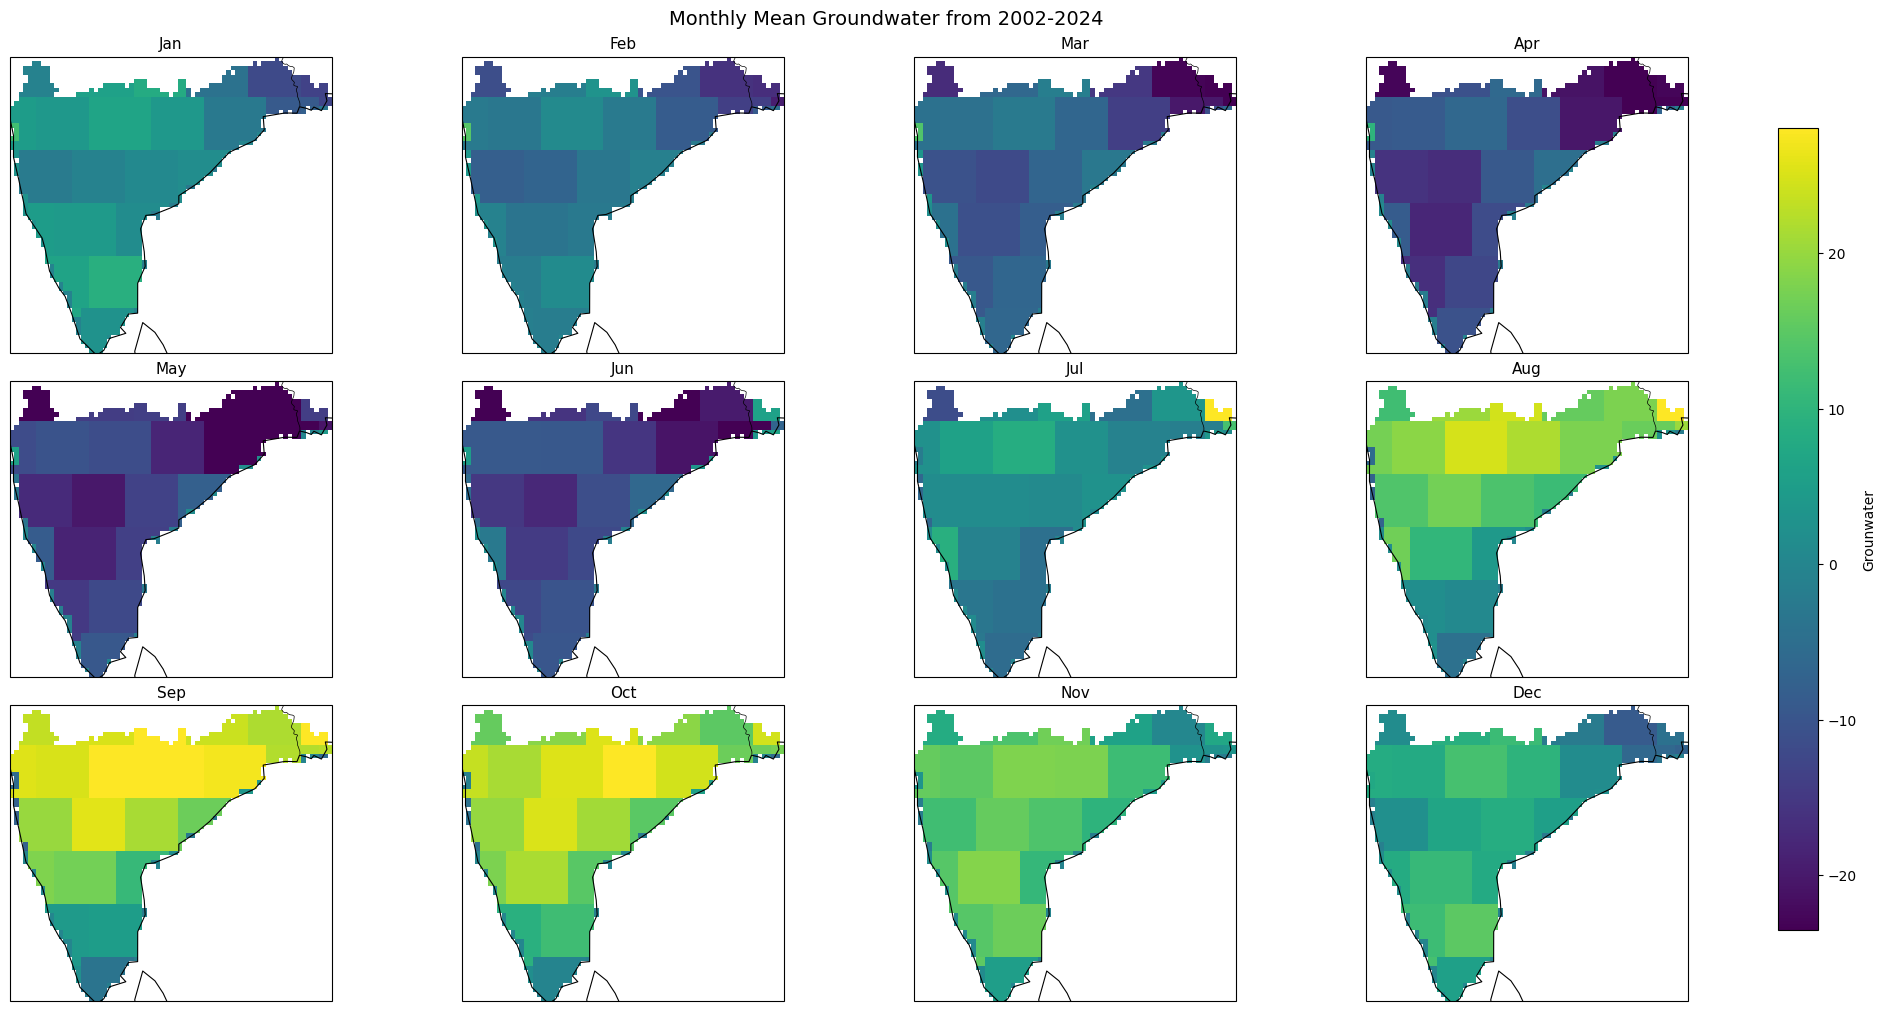

In [ ]:
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Groundwater/Groundwater_resample_crop.nc")
gw = ds["lwe_thickness"]

monthly_mean = gw.groupby("time.month").mean(dim="time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Grounwater")

plt.suptitle(
    "Monthly Mean Groundwater from 2002-2024",
    fontsize=14
)

plt.show()

#### Mann Kendall Test

In [ ]:
# -------------------------------
# Load groundwater data
# -------------------------------
rain = ds["lwe_thickness"]

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
rain_results = {}

for month in range(1, 13):

    # Select monthly rainfall
    rain_m = rain.sel(time=rain["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        rain_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    rain_results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


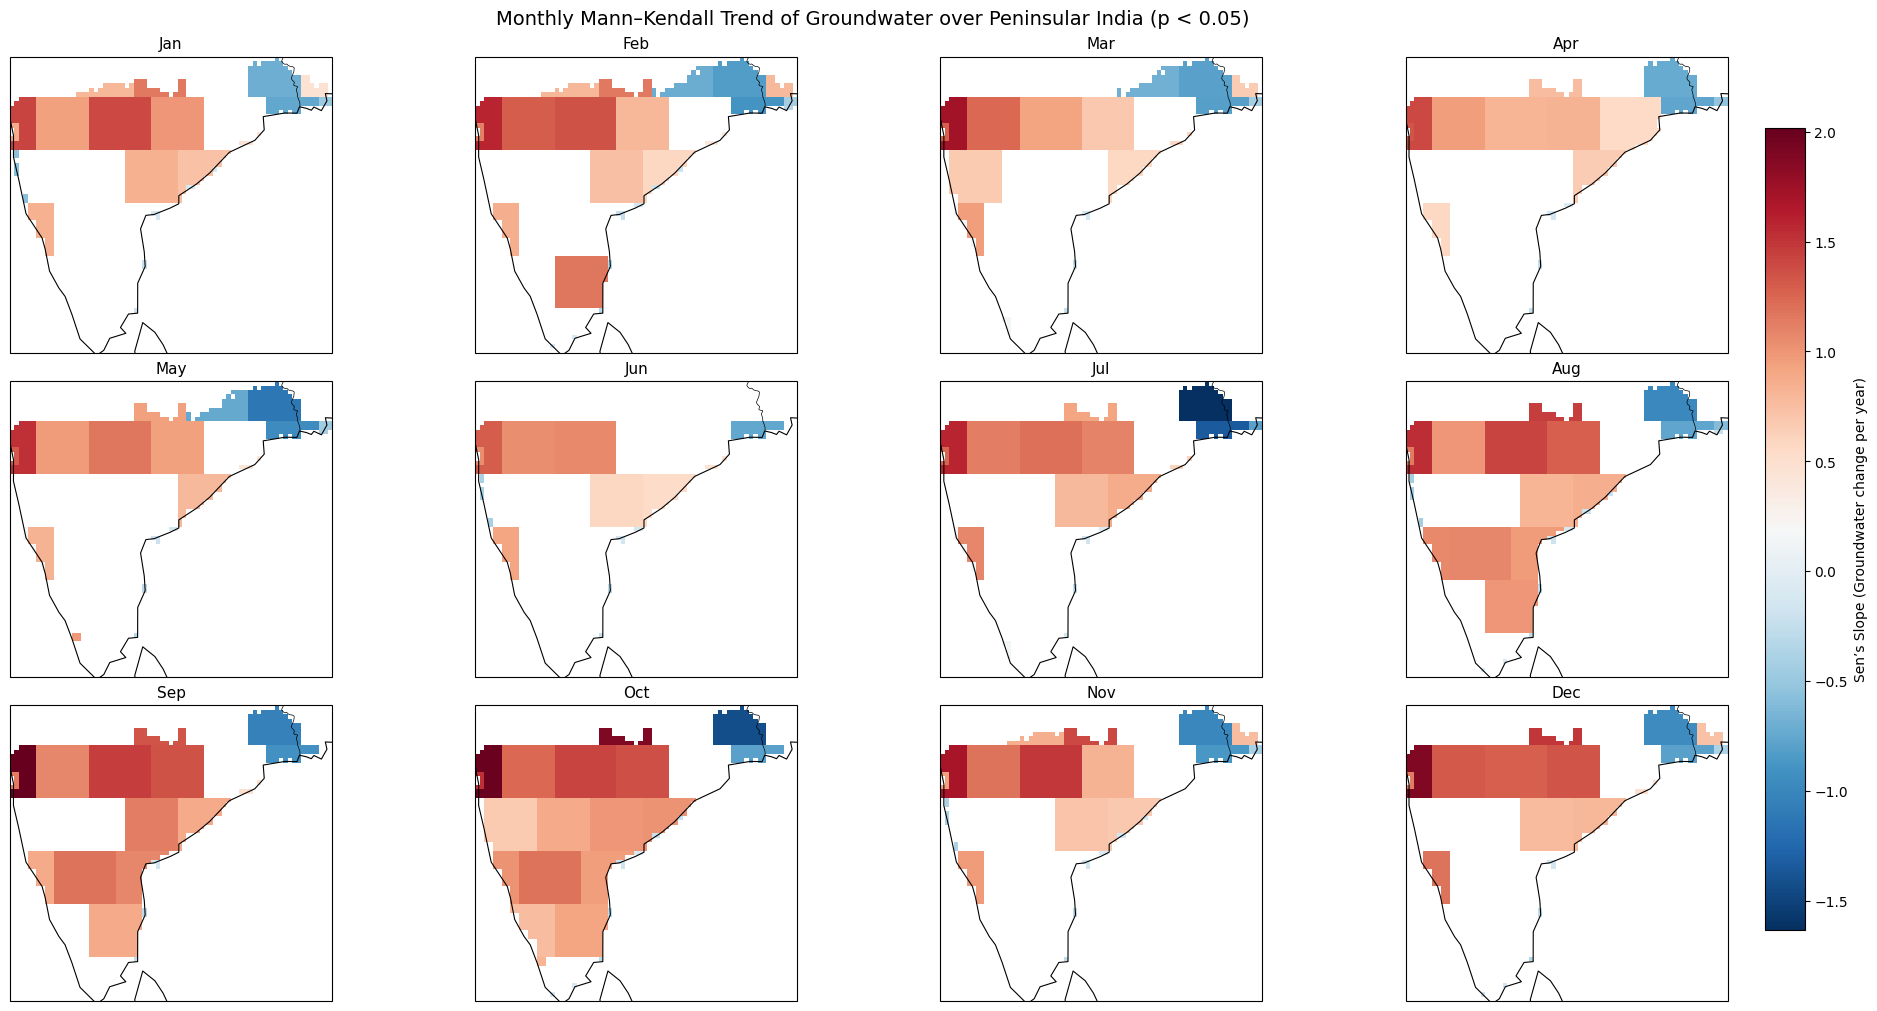

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant rainfall slopes only)
# ---------------------------------
all_rain_slopes = []

for m in range(1, 13):
    rain_slope = rain_results[m]["sens_slope"]
    significant_slope = rain_slope.where(rain_results[m]["p_value"] < 0.05)
    all_rain_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_rain_slopes])
vmax = np.nanmax([s.max().values for s in all_rain_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    rainfall_mk = rain_results[month]

    significant_slope = rainfall_mk["sens_slope"].where(
        rainfall_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Groundwater change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Groundwater over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()
